In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
data = pd.read_csv("insurance_claims.csv")
data.head()


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

daata1 = pd.read_csv("insurance_claims.csv")

le = LabelEncoder()
for col in daata1.columns:
    if daata1[col].dtype == 'O':
        daata1[col] = le.fit_transform(daata1[col])

x = daata1.iloc[:, 0:30]
y = daata1.iloc[:, 30:]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Features shape: (1000, 30)
Target shape: (1000, 10)
X_train: (800, 30)
X_test: (200, 30)
y_train: (800, 10)
y_test: (200, 10)


In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()

X_train = std_scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=x.columns)

X_test = std_scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=x.columns)


In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# CSV load
daata1 = pd.read_csv("insurance_claims.csv")

# Label encoding categorical columns
le = LabelEncoder()
for col in daata1.columns:
    if daata1[col].dtype == 'O':
        daata1[col] = le.fit_transform(daata1[col])

# Features and target
x = daata1.iloc[:, 0:30]
y = daata1.iloc[:, 30:]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Optional: check shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(800, 30) (200, 30) (800, 10) (200, 10)


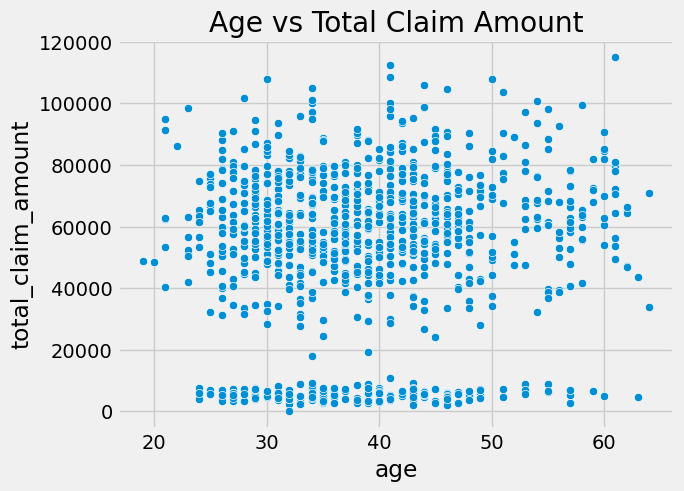

In [9]:
sns.scatterplot(x='age', y='total_claim_amount', data=data)

plt.title("Age vs Total Claim Amount")
plt.show()


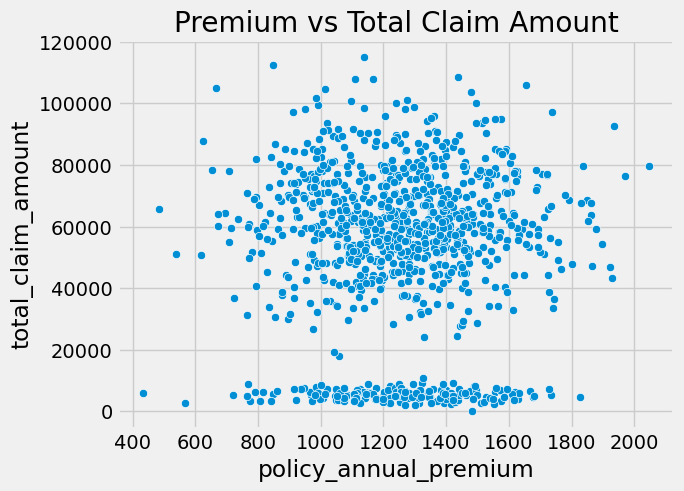

In [10]:
sns.scatterplot(x='policy_annual_premium', y='total_claim_amount', data=data)

plt.title("Premium vs Total Claim Amount")
plt.show()

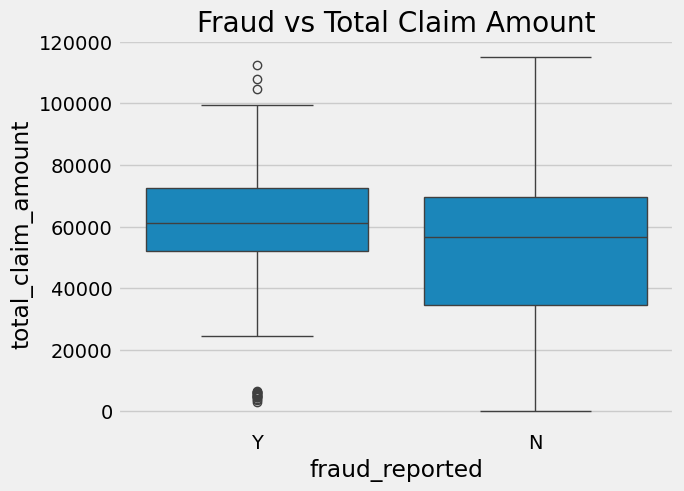

In [11]:
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=data)

plt.title("Fraud vs Total Claim Amount")
plt.show()

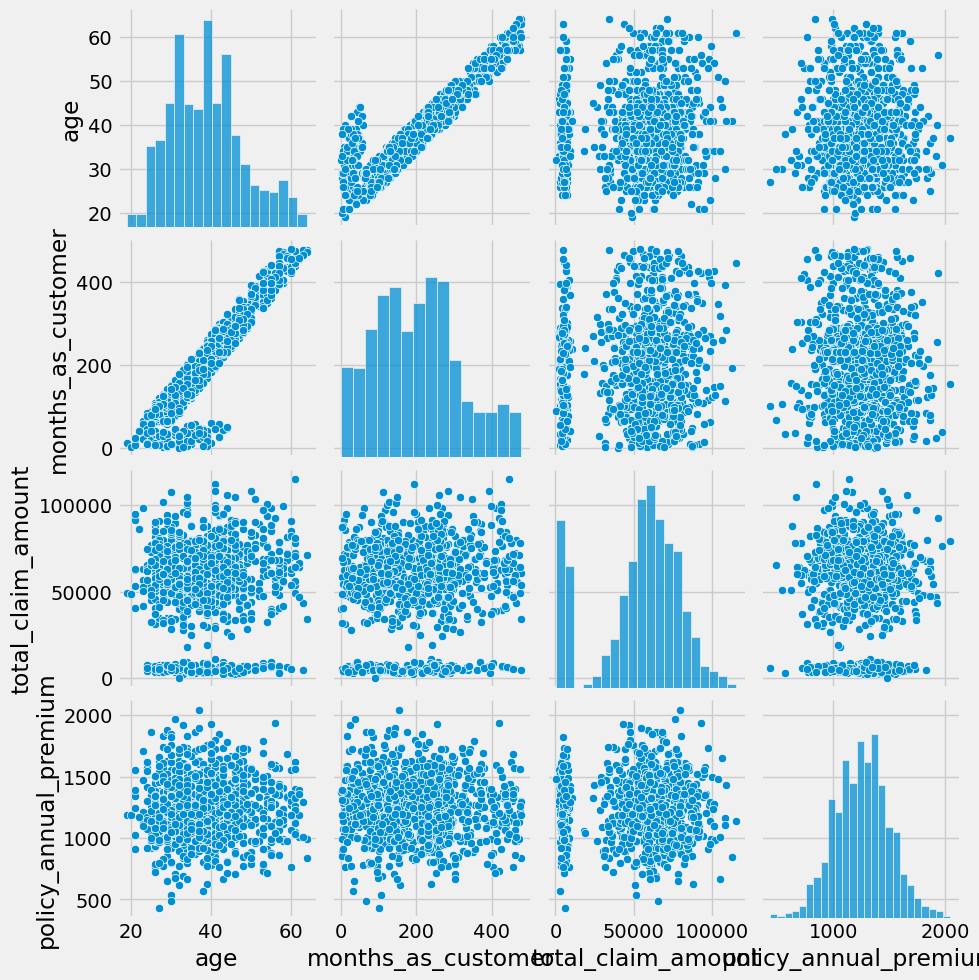

In [12]:
sns.pairplot(data[['age','months_as_customer','total_claim_amount','policy_annual_premium']])

plt.show()

In [13]:
data.select_dtypes(include='object').columns

Index(['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make', 'auto_model',
       'fraud_reported'],
      dtype='object')

In [14]:
data = data.replace("?", "Unknown")

In [15]:
data['fraud_reported'] = data['fraud_reported'].map({'Y':1, 'N':0})

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [17]:
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,532,2,1,1000,1406.91,0,466132,...,2,71610,6510,13020,52080,10,1,2004,1,NaN
1,228,42,342868,821,1,1,2000,1197.22,5000000,468176,...,1,5070,780,780,3510,8,12,2007,1,NaN
2,134,29,687698,186,2,0,2000,1413.14,5000000,430632,...,0,34650,7700,3850,23100,4,30,2007,0,NaN
3,256,41,227811,766,0,1,2000,1415.74,6000000,608117,...,0,63400,6340,6340,50720,3,34,2014,1,NaN
4,228,44,367455,181,0,2,1000,1583.91,6000000,610706,...,0,6500,1300,650,4550,0,31,2009,0,NaN


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   int64  
 4   policy_state                 1000 non-null   int64  
 5   policy_csl                   1000 non-null   int64  
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   int64  
 11  insured_education_level      1000 non-null   int64  
 12  insured_occupation           1000 non-null   int64  
 13  insured_hobbies    

In [19]:
from sklearn.preprocessing import StandardScaler
X = data.drop('fraud_reported', axis=1)
y = data['fraud_reported']
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [20]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,_c39
0,1.078140,0.990836,-0.095953,0.209500,1.187173,0.060937,-0.222383,0.616705,-0.479476,-0.489529,...,0.461838,1.270313,0.714257,-0.189283,1.165505,0.749653,0.856466,-1.645743,-0.183440,NaN
1,0.208995,0.334073,-0.791527,1.259397,-0.016856,0.060937,1.412784,-0.242521,1.697980,-0.461008,...,-1.338700,0.035801,-1.807312,-1.363822,-1.372696,-1.823346,0.360539,-0.657470,0.315491,NaN
2,-0.608002,-1.088913,0.550566,-1.047470,1.187173,-1.182668,1.412784,0.642233,1.697980,-0.984885,...,1.362107,-1.198712,-0.686362,0.054644,-0.736072,-0.785565,-0.631315,0.959702,0.315491,NaN
3,0.452355,0.224613,-1.239334,1.059589,-1.220886,0.060937,1.412784,0.652886,2.133471,1.491682,...,0.461838,-1.198712,0.403135,-0.224130,-0.219722,0.677607,-0.879279,1.319074,1.479664,NaN
4,0.208995,0.552994,-0.695834,-1.065634,-1.220886,1.304542,-0.222383,1.341980,2.133471,1.527808,...,-0.438431,-1.198712,-1.753121,-1.257232,-1.399654,-1.768252,-1.623169,1.049545,0.648112,NaN


In [21]:
X_scaled.shape

(1000, 39)

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
dt_model = DecisionTreeClassifier()
y_pred = dt_model.predict(X_test)

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [23]:
train_accuracy = dt_model.score(X_train, y_train)
print("Train Accuracy:", train_accuracy)

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [24]:
test_accuracy = dt_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

NameError: name 'y_pred' is not defined

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined

In [27]:
from sklearn.tree import DecisionTreeClassifier
dtc= DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
dtc_train_acc = accuracy.score(y_train, dtc.predict(X_train))
dtc_test_acc = accuracy.score(y_test,y_pred)

NameError: name 'accuracy' is not defined

In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [29]:
y_pred_knn = knn_model.predict(X_test)

NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [30]:
print("KNN Train Accuracy:", knn_model.score(X_train, y_train))
print("KNN Test Accuracy:", knn_model.score(X_test, y_test))

NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [31]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Train Accuracy:", rf_model.score(X_train, y_train))
print("Random Forest Test Accuracy:", rf_model.score(X_test, y_test))

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.735


In [33]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [34]:
y_pred_gb = gb_model.predict(X_test)

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [35]:
print("Gradient Boost Train Accuracy:", gb_model.score(X_train, y_train))
print("Gradient Boost Test Accuracy:", gb_model.score(X_test, y_test))

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [36]:
import pickle

pickle.dump(rf_model, open('fraud_model.pkl', 'wb'))
model = pickle.load(open('fraud_model.pkl', 'rb'))
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 39)
Test shape: (200, 39)


In [37]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

print("Train Accuracy:", dt_model.score(X_train, y_train))
print("Test Accuracy:", dt_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.765


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.73


In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

print("Train Accuracy:", gb_model.score(X_train, y_train))
print("Test Accuracy:", gb_model.score(X_test, y_test))

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [40]:
data.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted             0
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [41]:
data = data.fillna(data.mean())
data = data.fillna(0)
X = data.drop('fraud_reported', axis=1)
y = data['fraud_reported']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

print("Train Accuracy:", gb_model.score(X_train, y_train))
print("Test Accuracy:", gb_model.score(X_test, y_test))

Train Accuracy: 0.97625
Test Accuracy: 0.79


In [43]:
y_pred = rf_model.predict(X_test)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


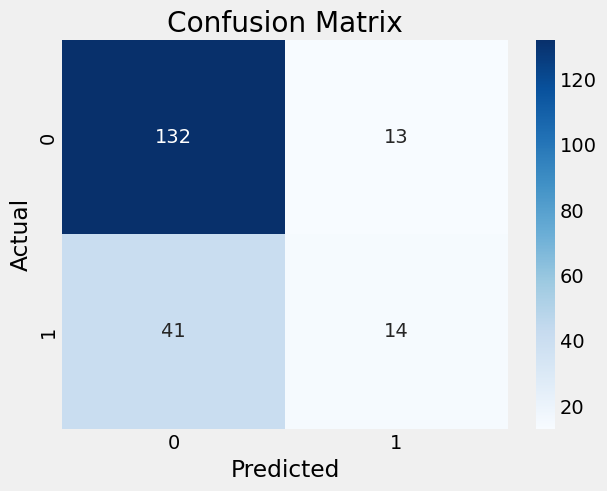

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       145
           1       0.52      0.25      0.34        55

    accuracy                           0.73       200
   macro avg       0.64      0.58      0.59       200
weighted avg       0.70      0.73      0.70       200



In [46]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.34146341463414637


In [47]:
import pickle

pickle.dump(rf_model, open('fraud_detection_model.pkl', 'wb'))

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
X = data.drop('fraud_reported', axis=1)
y = data['fraud_reported']

In [50]:
import pandas as pd
import numpy as np

In [51]:
data = pd.read_csv("insurance_claims.csv")

data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [52]:
data = data.replace("?", np.nan)
data = data.drop(['policy_bind_date','incident_date'], axis=1, errors='ignore')
data = pd.get_dummies(data)
data = data.fillna(0)
X = data.drop('fraud_reported', axis=1)
y = data['fraud_reported']

KeyError: "['fraud_reported'] not found in axis"

In [53]:
data.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       ...
       'auto_model_RSX', 'auto_model_Silverado', 'auto_model_TL',
       'auto_model_Tahoe', 'auto_model_Ultima', 'auto_model_Wrangler',
       'auto_model_X5', 'auto_model_X6', 'fraud_reported_N',
       'fraud_reported_Y'],
      dtype='object', length=1162)

In [54]:
X = data.drop(['fraud_reported_N','fraud_reported_Y'], axis=1)
y = data['fraud_reported_Y']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.72


In [56]:
import pickle

pickle.dump(rf_model, open("fraud_detection_model.pkl", "wb"))
X = data.drop(['fraud_reported_N','fraud_reported_Y'], axis=1)
y = data['fraud_reported_Y']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt_model.score(X_test, y_test))

Decision Tree Accuracy: 0.785


In [58]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[145   0]
 [ 55   0]]
              precision    recall  f1-score   support

       False       0.72      1.00      0.84       145
        True       0.00      0.00      0.00        55

    accuracy                           0.72       200
   macro avg       0.36      0.50      0.42       200
weighted avg       0.53      0.72      0.61       200



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [60]:
import pickle

pickle.dump(rf_model, open("fraud_detection_model.pkl", "wb"))
import pandas as pd

data = pd.read_csv("insurance_claims.csv")

data = data.replace("?",0)

# Select only the features used in the form
X = data[['age','months_as_customer','policy_deductable','total_claim_amount']]

y = data['fraud_reported']
y = y.map({'N':0,'Y':1})

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
mport pickle

pickle.dump(model,open("fraud_detection_model.pkl","wb"))
import pandas as pd

data = pd.read_csv("insurance_claims.csv")

data = data.replace("?", 0)

# Use only the features that are in the HTML form
X = data[['age','months_as_customer','policy_deductable','total_claim_amount']]

y = data['fraud_reported']
y = y.map({'N':0,'Y':1})

SyntaxError: invalid syntax (1036580542.py, line 1)

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
import pickle

pickle.dump(model, open("fraud_detection_model.pkl", "wb"))
print(X.shape)

(1000, 4)


In [65]:
X = data[['age','months_as_customer','policy_deductable','total_claim_amount']]
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
import pickle

pickle.dump(model, open("fraud_detection_model.pkl", "wb"))
print(data['fraud_reported'].value_counts())

fraud_reported
N    753
Y    247
Name: count, dtype: int64


In [67]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.675


In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
data = pd.read_csv("insurance_claims.csv")
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17-10-2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27-06-2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06-09-2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25-05-1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06-06-2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [70]:
data['fraud_reported'] = data['fraud_reported'].map({'N':0,'Y':1})
X = data[['age','months_as_customer','policy_deductable','total_claim_amount']]
y = data['fraud_reported']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)

model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
print("Train Accuracy:",model.score(X_train,y_train))
print("Test Accuracy:",model.score(X_test,y_test))

Train Accuracy: 1.0
Test Accuracy: 0.675


In [72]:
pickle.dump(model,open("fraud_detection_model.pkl","wb"))